# PointNet Classification on ModelNet10 (PyTorch, Colab Ready)

This notebook builds a simple end-to-end PointNet-style classifier for ModelNet10.

By the end, you will:
- Download and prepare ModelNet10 as point clouds.
- Train a compact PointNet classifier in PyTorch.
- Evaluate performance with accuracy, confusion matrix, and sample predictions.
- Save reproducible artifacts to `sample_outputs/`.

In [1]:
# Torch is usually pre-installed in Colab, so we only install the extra utilities.
!pip install -q trimesh scikit-learn pandas matplotlib tqdm

## 0. Setup: Imports, Paths, and Utility Functions

- Data is stored under `data/`.
- Generated artifacts are written to `sample_outputs/`.
- Random seeds are fixed so results are easier to reproduce and explain.

In [2]:
import os
import random
import zipfile

from pathlib import Path

import matplotlib.pyplot as plt
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import trimesh

from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "sample_outputs"


def resolve_output_path(filename: str) -> Path:
  OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
  return OUTPUT_DIR / filename


def set_seed(seed: int = 42) -> None:
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 1. Download and Inspect ModelNet10

ModelNet10 is a 3D object dataset with 10 classes (chair, table, sofa, etc.).
In this section, we download it once, extract it, and build a class index map that the model can use.

In [3]:
MODELNET10_URLS = [
  "http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip",
  "https://modelnet.cs.princeton.edu/ModelNet10.zip",
  "http://modelnet.cs.princeton.edu/ModelNet10.zip"
]

MODELNET_ARCHIVE = DATA_DIR / "ModelNet10.zip"
MODELNET_ROOT = DATA_DIR / "ModelNet10"


def archive_is_valid_zip(archive_path: Path) -> bool:
  if not archive_path.exists():
    return False
  try:
    with zipfile.ZipFile(archive_path, "r") as zip_ref:
      return len(zip_ref.namelist()) > 0
  except zipfile.BadZipFile:
    return False


def modelnet_root_is_ready(root_path: Path) -> bool:
  if not root_path.exists():
    return False

  for class_dir in root_path.iterdir():
    if not class_dir.is_dir():
      continue
    train_dir = class_dir / "train"
    test_dir = class_dir / "test"
    if train_dir.exists() and test_dir.exists():
      return True
  return False


def download_modelnet10() -> Path:
  if modelnet_root_is_ready(MODELNET_ROOT):
    print(f"ModelNet10 already available at: {MODELNET_ROOT}")
    return MODELNET_ROOT

  if MODELNET_ROOT.exists():
    print("Existing ModelNet10 folder looks incomplete. Rebuilding from archive.")

  DATA_DIR.mkdir(parents=True, exist_ok=True)

  # Guard against partial or invalid archives from interrupted/failed downloads.
  if MODELNET_ARCHIVE.exists() and not archive_is_valid_zip(MODELNET_ARCHIVE):
    print(f"Removing invalid archive: {MODELNET_ARCHIVE}")
    MODELNET_ARCHIVE.unlink()

  if not MODELNET_ARCHIVE.exists():
    last_error = None
    for url in MODELNET10_URLS:
      try:
        print(f"Downloading ModelNet10 from: {url}")
        response = requests.get(
          url,
          stream=True,
          timeout=120,
          headers={"User-Agent": "Mozilla/5.0"}
        )
        response.raise_for_status()

        with open(MODELNET_ARCHIVE, "wb") as archive_file:
          for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
              archive_file.write(chunk)

        if not archive_is_valid_zip(MODELNET_ARCHIVE):
          MODELNET_ARCHIVE.unlink(missing_ok=True)
          raise RuntimeError("Downloaded file is not a valid zip archive")
        print(f"Downloaded archive to: {MODELNET_ARCHIVE}")
        break
      except Exception as exc:
        last_error = exc
        MODELNET_ARCHIVE.unlink(missing_ok=True)
        print(f"Download failed from {url}: {exc}")
    if not MODELNET_ARCHIVE.exists():
      raise RuntimeError(
        "Could not download ModelNet10 from known URLs. "
        f"Last error: {last_error}. "
        "Fallback: manually download ModelNet10.zip from "
        "https://modelnet.cs.princeton.edu/download.html, place it at "
        f"{MODELNET_ARCHIVE}, then rerun this cell."
      )

  print("Extracting ModelNet10 archive...")
  with zipfile.ZipFile(MODELNET_ARCHIVE, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

  if not MODELNET_ROOT.exists():
    raise FileNotFoundError(f"Expected extracted folder not found: {MODELNET_ROOT}")

  print(f"ModelNet10 ready at: {MODELNET_ROOT}")
  return MODELNET_ROOT


MODELNET_ROOT = download_modelnet10()

CLASS_NAMES = sorted([
  folder.name
  for folder in MODELNET_ROOT.iterdir()
  if folder.is_dir() and (folder / "train").exists() and (folder / "test").exists()
])
CLASS_TO_INDEX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {idx: class_name for class_name, idx in CLASS_TO_INDEX.items()}

print(f"Discovered {len(CLASS_NAMES)} classes:")
print(CLASS_NAMES)

Downloaded archive to: /content/data/ModelNet10.zip
Extracting ModelNet10 archive...
ModelNet10 ready at: /content/data/ModelNet10
Discovered 10 classes:
['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']


## 2. Build the Point-Cloud Dataset Pipeline

PointNet expects a fixed number of points per shape.
So we will:
- Load each mesh (`.off`) from ModelNet10.
- Sample `N` points from the mesh surface.
- Normalize each point cloud to a unit sphere.
- Return tensors in a format that works directly with PyTorch `DataLoader`.

In [4]:
def normalize_point_cloud(points: np.ndarray) -> np.ndarray:
  center = points.mean(axis=0)
  points = points - center
  scale = np.linalg.norm(points, axis=1).max()
  if scale == 0:
    return points
  return points / scale


def load_mesh_as_points(
  mesh_path: Path,
  num_points: int,
  rng: np.random.Generator
) -> np.ndarray:
  mesh = trimesh.load(mesh_path, force="mesh")

  if isinstance(mesh, trimesh.Scene):
    if not mesh.geometry:
      raise ValueError(f"No geometry found in scene: {mesh_path}")
    mesh = trimesh.util.concatenate(tuple(mesh.geometry.values()))

  if not isinstance(mesh, trimesh.Trimesh):
    raise TypeError(f"Unsupported mesh type at {mesh_path}: {type(mesh)}")

  if mesh.vertices.shape[0] == 0:
    raise ValueError(f"Mesh has no vertices: {mesh_path}")

  if mesh.faces is not None and len(mesh.faces) > 0:
    points = mesh.sample(num_points)
  else:
    vertex_indices = rng.choice(mesh.vertices.shape[0], size=num_points, replace=True)
    points = mesh.vertices[vertex_indices]

  return normalize_point_cloud(points.astype(np.float32))


class ModelNet10PointCloudDataset(Dataset):
  def __init__(
    self,
    root_dir: Path,
    split: str,
    class_to_index: dict,
    num_points: int = 1024,
    augment: bool = False,
    max_samples: int | None = None,
    seed: int = 42
  ):
    self.root_dir = Path(root_dir)
    self.split = split
    self.class_to_index = class_to_index
    self.num_points = num_points
    self.augment = augment
    self.rng = np.random.default_rng(seed)

    self.samples = []
    for class_name, class_idx in self.class_to_index.items():
      split_dir = self.root_dir / class_name / split
      if not split_dir.exists():
        continue
      for mesh_path in sorted(split_dir.glob("*.off")):
        self.samples.append((mesh_path, class_idx, class_name))

    if max_samples is not None and max_samples < len(self.samples):
      keep_indices = self.rng.choice(len(self.samples), size=max_samples, replace=False)
      self.samples = [self.samples[idx] for idx in sorted(keep_indices.tolist())]

  def __len__(self) -> int:
    return len(self.samples)

  def apply_augmentation(self, points: np.ndarray) -> np.ndarray:
    angle = self.rng.uniform(0, 2 * np.pi)
    cos_val = np.cos(angle)
    sin_val = np.sin(angle)
    rotation = np.array([
      [cos_val, 0.0, sin_val],
      [0.0, 1.0, 0.0],
      [-sin_val, 0.0, cos_val]
    ], dtype=np.float32)
    points = points @ rotation.T

    jitter = self.rng.normal(loc=0.0, scale=0.01, size=points.shape).astype(np.float32)
    points = points + jitter
    return points.astype(np.float32)

  def __getitem__(self, index: int):
    mesh_path, class_idx, class_name = self.samples[index]
    points = load_mesh_as_points(mesh_path, self.num_points, self.rng)

    if self.augment:
      points = self.apply_augmentation(points)

    points_tensor = torch.from_numpy(points)
    label_tensor = torch.tensor(class_idx, dtype=torch.long)
    return points_tensor, label_tensor, class_name, mesh_path.name

In [5]:
NUM_POINTS = 1024
BATCH_SIZE = 32
NUM_EPOCHS = 8
LEARNING_RATE = 1e-3

# Set True if you want a faster smoke run in Colab.
USE_SMALL_SUBSET = False
MAX_TRAIN_SAMPLES = 2048 if USE_SMALL_SUBSET else None
MAX_TEST_SAMPLES = 512 if USE_SMALL_SUBSET else None

train_dataset = ModelNet10PointCloudDataset(
  root_dir=MODELNET_ROOT,
  split="train",
  class_to_index=CLASS_TO_INDEX,
  num_points=NUM_POINTS,
  augment=True,
  max_samples=MAX_TRAIN_SAMPLES,
  seed=42
)

test_dataset = ModelNet10PointCloudDataset(
  root_dir=MODELNET_ROOT,
  split="test",
  class_to_index=CLASS_TO_INDEX,
  num_points=NUM_POINTS,
  augment=False,
  max_samples=MAX_TEST_SAMPLES,
  seed=123
)

# Notebook-safe default: single-process loading avoids worker shutdown issues
# in Colab/Jupyter when cells are interrupted or re-run out of order.
USE_MULTIPROCESS_DATALOADER = False
if USE_MULTIPROCESS_DATALOADER:
  num_workers = 2 if os.name != "nt" else 0
else:
  num_workers = 0

train_loader = DataLoader(
  train_dataset,
  batch_size=BATCH_SIZE,
  shuffle=True,
  num_workers=num_workers,
  pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
  test_dataset,
  batch_size=BATCH_SIZE,
  shuffle=False,
  num_workers=num_workers,
  pin_memory=torch.cuda.is_available()
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

train_distribution = (
  pd.Series([sample[2] for sample in train_dataset.samples])
  .value_counts()
  .reindex(CLASS_NAMES)
  .fillna(0)
  .astype(int)
  .rename("train_count")
)

test_distribution = (
  pd.Series([sample[2] for sample in test_dataset.samples])
  .value_counts()
  .reindex(CLASS_NAMES)
  .fillna(0)
  .astype(int)
  .rename("test_count")
)

distribution_df = pd.concat([train_distribution, test_distribution], axis=1)
distribution_df

Train samples: 3991
Test samples: 908
Classes (10): ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']


,train_count,test_count
bathtub,106,50
bed,515,100
chair,889,100
desk,200,86
dresser,200,86
monitor,465,100
night_stand,200,86
sofa,680,100
table,392,100
toilet,344,100


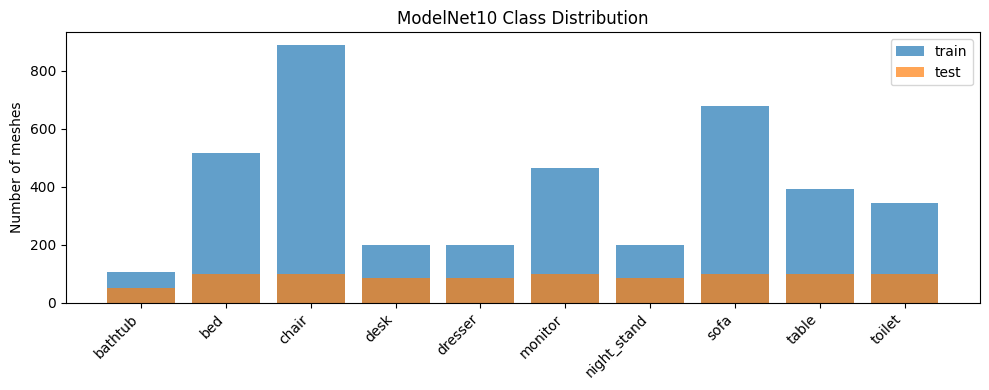

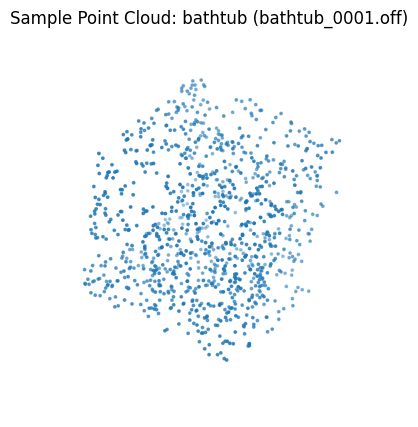

In [6]:
plt.figure(figsize=(10, 4))
plt.bar(distribution_df.index, distribution_df["train_count"], alpha=0.7, label="train")
plt.bar(distribution_df.index, distribution_df["test_count"], alpha=0.7, label="test")
plt.xticks(rotation=45, ha="right")
plt.title("ModelNet10 Class Distribution")
plt.ylabel("Number of meshes")
plt.legend()
plt.tight_layout()
plt.show()

sample_points, sample_label, sample_class_name, sample_file = train_dataset[0]
sample_np = sample_points.numpy()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")
ax.scatter(sample_np[:, 0], sample_np[:, 1], sample_np[:, 2], s=3)
ax.set_title(f"Sample Point Cloud: {sample_class_name} ({sample_file})")
ax.set_box_aspect((1, 1, 1))
ax.axis("off")
plt.show()

## 3. Define a Simple PointNet Classifier

PointNet works directly on unordered point sets.
Our compact version has three parts:
- **Input transform network**: learns a small alignment matrix.
- **Feature encoder**: extracts global shape features with shared MLP layers.
- **Classifier head**: maps features to one of the 10 ModelNet classes.

In [7]:
class InputTransformNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv1d(3, 64, 1)
    self.conv2 = nn.Conv1d(64, 128, 1)
    self.conv3 = nn.Conv1d(128, 1024, 1)

    self.bn1 = nn.BatchNorm1d(64)
    self.bn2 = nn.BatchNorm1d(128)
    self.bn3 = nn.BatchNorm1d(1024)

    self.fc1 = nn.Linear(1024, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 9)

    self.fc_bn1 = nn.BatchNorm1d(512)
    self.fc_bn2 = nn.BatchNorm1d(256)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    batch_size = x.size(0)

    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = F.relu(self.bn3(self.conv3(x)))

    x = torch.max(x, dim=2).values
    x = F.relu(self.fc_bn1(self.fc1(x)))
    x = F.relu(self.fc_bn2(self.fc2(x)))
    x = self.fc3(x)

    identity = torch.eye(3, device=x.device).view(1, 9).repeat(batch_size, 1)
    x = x + identity
    return x.view(-1, 3, 3)


class PointNetEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.input_transform = InputTransformNet()

    self.conv1 = nn.Conv1d(3, 64, 1)
    self.conv2 = nn.Conv1d(64, 128, 1)
    self.conv3 = nn.Conv1d(128, 256, 1)

    self.bn1 = nn.BatchNorm1d(64)
    self.bn2 = nn.BatchNorm1d(128)
    self.bn3 = nn.BatchNorm1d(256)

  def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    transform = self.input_transform(x)

    x = x.transpose(1, 2)
    x = torch.bmm(x, transform)
    x = x.transpose(1, 2)

    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = F.relu(self.bn3(self.conv3(x)))

    global_features = torch.max(x, dim=2).values
    return global_features, transform


class PointNetClassifier(nn.Module):
  def __init__(self, num_classes: int):
    super().__init__()
    self.encoder = PointNetEncoder()

    self.fc1 = nn.Linear(256, 256)
    self.fc2 = nn.Linear(256, 128)
    self.fc3 = nn.Linear(128, num_classes)

    self.bn1 = nn.BatchNorm1d(256)
    self.bn2 = nn.BatchNorm1d(128)
    self.dropout = nn.Dropout(p=0.3)

  def forward(self, points: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    # points shape: [batch, num_points, 3]
    x = points.transpose(1, 2)
    features, transform = self.encoder(x)

    x = F.relu(self.bn1(self.fc1(features)))
    x = F.relu(self.bn2(self.fc2(x)))
    x = self.dropout(x)
    logits = self.fc3(x)
    return logits, transform


model = PointNetClassifier(num_classes=len(CLASS_NAMES)).to(DEVICE)
print(model)

PointNetClassifier(
  (encoder): PointNetEncoder(
    (input_transform): InputTransformNet(
      (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (fc1): Linear(in_features=1024, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=True)
      (fc3): Linear(in_features=256, out_features=9, bias=True)
      (fc_bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (fc_bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv1): Conv1d(3, 64, kernel_size=(1,)

## 4. Train the PointNet Model

We will train with a standard cross-entropy objective and track:
- Training loss and accuracy
- Test loss and accuracy
- Best checkpoint by test accuracy

This keeps the workflow simple and clear for first-time 3D classification experiments.

In [8]:
def transform_regularizer(transform: torch.Tensor) -> torch.Tensor:
  batch_size = transform.size(0)
  k = transform.size(1)
  identity = torch.eye(k, device=transform.device).unsqueeze(0).repeat(batch_size, 1, 1)
  product = torch.bmm(transform, transform.transpose(1, 2))
  return torch.mean(torch.norm(identity - product, dim=(1, 2)))


def train_one_epoch(
  model: nn.Module,
  loader: DataLoader,
  optimizer: torch.optim.Optimizer,
  device: torch.device,
  reg_weight: float = 1e-3
) -> tuple[float, float]:
  model.train()
  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  for points, labels, _, _ in tqdm(loader, desc="Train", leave=False):
    points = points.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    logits, transform = model(points)

    cls_loss = F.cross_entropy(logits, labels)
    reg_loss = transform_regularizer(transform)
    loss = cls_loss + reg_weight * reg_loss

    loss.backward()
    optimizer.step()

    batch_size = labels.size(0)
    total_loss += loss.item() * batch_size
    total_correct += (logits.argmax(dim=1) == labels).sum().item()
    total_samples += batch_size

  epoch_loss = total_loss / max(total_samples, 1)
  epoch_acc = total_correct / max(total_samples, 1)
  return epoch_loss, epoch_acc


def evaluate_one_epoch(
  model: nn.Module,
  loader: DataLoader,
  device: torch.device,
  reg_weight: float = 1e-3
) -> tuple[float, float]:
  model.eval()
  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    for points, labels, _, _ in tqdm(loader, desc="Eval", leave=False):
      points = points.to(device)
      labels = labels.to(device)

      logits, transform = model(points)
      cls_loss = F.cross_entropy(logits, labels)
      reg_loss = transform_regularizer(transform)
      loss = cls_loss + reg_weight * reg_loss

      batch_size = labels.size(0)
      total_loss += loss.item() * batch_size
      total_correct += (logits.argmax(dim=1) == labels).sum().item()
      total_samples += batch_size

  epoch_loss = total_loss / max(total_samples, 1)
  epoch_acc = total_correct / max(total_samples, 1)
  return epoch_loss, epoch_acc

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history_rows = []
best_test_acc = -1.0
best_model_path = resolve_output_path("modelnet10_pointnet_best.pth")

for epoch in range(1, NUM_EPOCHS + 1):
  train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, DEVICE)
  test_loss, test_acc = evaluate_one_epoch(model, test_loader, DEVICE)

  history_rows.append({
    "epoch": epoch,
    "train_loss": train_loss,
    "train_acc": train_acc,
    "test_loss": test_loss,
    "test_acc": test_acc
  })

  print(
    f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
    f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
    f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
  )

  if test_acc > best_test_acc:
    best_test_acc = test_acc
    torch.save(model.state_dict(), best_model_path)

history_df = pd.DataFrame(history_rows)
history_path = resolve_output_path("modelnet10_training_history.csv")
history_df.to_csv(history_path, index=False)

print(f"Saved best model to: {best_model_path}")
print(f"Saved training history to: {history_path}")
history_df

Train:   0%|          | 0/125 [00:00<?, ?it/s]

Eval:   0%|          | 0/29 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x795e00568f40><function _MultiProcessingDataLoaderIter.__del__ at 0x795e00568f40>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()    
Exception ignored in: self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x795e00568f40>
    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():    
Traceback (most recent call last):
if w.is_alive(): Exception ignored in: 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/datal

Epoch 01/8 | train_loss=1.2522, train_acc=0.6059, test_loss=1.8494, test_acc=0.4306


Train:   0%|          | 0/125 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x795e00568f40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
      Exception ignored in:  ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x795e00568f40>
^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x795e00568f40> assert self._parent_

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
axes[0].plot(history_df["epoch"], history_df["test_loss"], marker="o", label="test")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train")
axes[1].plot(history_df["epoch"], history_df["test_acc"], marker="o", label="test")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()

curves_path = resolve_output_path("modelnet10_training_curves.png")
fig.savefig(curves_path, dpi=150)
print(f"Saved training curves to: {curves_path}")
plt.show()

## 5. Evaluate and Explain the Results

Now we evaluate the best saved model and create artifacts that are easy to share:
- Test accuracy
- Confusion matrix CSV + plot
- Classification report CSV
- Per-sample predictions CSV

These outputs are useful for both debugging and explaining what the model learned.

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_true = []
all_pred = []
prediction_rows = []

with torch.no_grad():
  for points, labels, true_class_names, file_names in tqdm(test_loader, desc="Final eval"):
    points = points.to(DEVICE)
    logits, _ = model(points)

    pred_indices = logits.argmax(dim=1).cpu().numpy()
    true_indices = labels.numpy()

    all_true.extend(true_indices.tolist())
    all_pred.extend(pred_indices.tolist())

    for batch_idx, pred_idx in enumerate(pred_indices.tolist()):
      true_idx = int(true_indices[batch_idx])
      prediction_rows.append({
        "file_name": file_names[batch_idx],
        "true_class": INDEX_TO_CLASS[true_idx],
        "predicted_class": INDEX_TO_CLASS[pred_idx],
        "is_correct": int(pred_idx == true_idx)
      })

test_accuracy = float(np.mean(np.array(all_true) == np.array(all_pred)))
print(f"Best-checkpoint test accuracy: {test_accuracy:.4f}")

cm = confusion_matrix(all_true, all_pred, labels=list(range(len(CLASS_NAMES))))
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

report_dict = classification_report(
  all_true,
  all_pred,
  labels=list(range(len(CLASS_NAMES))),
  target_names=CLASS_NAMES,
  output_dict=True,
  zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()

predictions_df = pd.DataFrame(prediction_rows)

cm_path = resolve_output_path("modelnet10_confusion_matrix.csv")
report_path = resolve_output_path("modelnet10_classification_report.csv")
predictions_path = resolve_output_path("modelnet10_test_predictions.csv")

cm_df.to_csv(cm_path)
report_df.to_csv(report_path)
predictions_df.to_csv(predictions_path, index=False)

print(f"Saved confusion matrix CSV: {cm_path}")
print(f"Saved classification report CSV: {report_path}")
print(f"Saved per-sample predictions CSV: {predictions_path}")

report_df.round(4)

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
image = ax.imshow(cm_df.values, cmap="Blues")

ax.set_title("ModelNet10 Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)

for row in range(cm_df.shape[0]):
  for col in range(cm_df.shape[1]):
    value = cm_df.values[row, col]
    color = "white" if value > cm_df.values.max() * 0.5 else "black"
    ax.text(col, row, int(value), ha="center", va="center", color=color, fontsize=8)

fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()

cm_plot_path = resolve_output_path("modelnet10_confusion_matrix.png")
fig.savefig(cm_plot_path, dpi=150)
print(f"Saved confusion matrix plot: {cm_plot_path}")
plt.show()

print("How to explain this matrix:")
print("- Rows are the true classes.")
print("- Columns are the model predictions.")
print("- Higher values on the diagonal mean better class-specific performance.")

## 6. Inference Demo on Held-Out Samples

To make this easier to explain, we now pick a few random test shapes and show:
- The true class
- The predicted class
- A colored point cloud (`green` if correct, `red` if incorrect)

This gives a quick visual sanity check of model behavior.

In [ ]:
if len(predictions_df) == 0:
  raise RuntimeError("predictions_df is empty. Run the evaluation cell first.")

demo_count = min(6, len(predictions_df))
demo_rows = predictions_df.sample(n=demo_count, random_state=42).reset_index(drop=True)

demo_path = resolve_output_path("modelnet10_sample_predictions.csv")
demo_rows.to_csv(demo_path, index=False)
print(f"Saved demo predictions to: {demo_path}")

fig = plt.figure(figsize=(15, 8))
for plot_idx, row in demo_rows.iterrows():
  mesh_path = MODELNET_ROOT / row["true_class"] / "test" / row["file_name"]
  points = load_mesh_as_points(mesh_path, NUM_POINTS, np.random.default_rng(100 + plot_idx))

  ax = fig.add_subplot(2, 3, plot_idx + 1, projection="3d")
  point_color = "tab:green" if row["is_correct"] == 1 else "tab:red"
  ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2, c=point_color)
  ax.set_title(f"T: {row['true_class']}\nP: {row['predicted_class']}", fontsize=10)
  ax.set_box_aspect((1, 1, 1))
  ax.axis("off")

plt.tight_layout()
plt.show()

demo_rows

## 7. Wrap-Up and Simple Talk Track

You now have an end-to-end 3D classification notebook:
1. Downloaded and prepared ModelNet10.
2. Converted meshes into normalized point clouds.
3. Trained a compact PointNet classifier in PyTorch.
4. Evaluated performance with reusable CSV/PNG artifacts.
5. Ran inference on held-out examples.

### How to explain this simply to someone else
- "PointNet looks at a set of 3D points instead of a rendered image."
- "Each shape is normalized, so the model focuses on geometry, not absolute position."
- "A shared MLP extracts per-point features, then max pooling builds one global shape descriptor."
- "The classifier maps that descriptor to one of the 10 object classes."
- "We validate with accuracy plus confusion matrix to see where classes are confused."

### Easy next upgrades
- Train longer (`NUM_EPOCHS`) for better accuracy.
- Increase `NUM_POINTS` if Colab memory allows.
- Add stronger augmentation (random scaling, dropout, jitter tuning).
- Replace the compact model with full PointNet or PointNet++ variants.